# GABLS1 LES Intercomparison Study for Stable Boundary Layers: Structure Functions

*Last updated: May 2026*


For case setup and physical parameters, see the [Description](SBL_GABLS1_Description.ipynb) notebook.

Longitudinal structure functions $S_q(r) = \langle |f(x+r) - f(x)|^q \rangle$ (orders $q = 1, 2, 3$) of the streamwise velocity $u$ and potential temperature $\theta$ are computed at four height levels. The 1-D structure function is computed along $x$ for each $y$ row and then averaged over $y$. Reference run: `256x256x256_LASDD_SM_SP` at $t = 9$ h.

## Setup

In [60]:
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### Output directory

In [61]:
def find_repo_root(start=None):
    path = Path(start or ('__file__' in globals() and __file__) or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / 'examples').is_dir() and (candidate / 'docs').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate JAXALFA0.1 repository root')

BaseDir = find_repo_root()

RunDir    = BaseDir / 'examples/SBL_GABLS1/runs/256x256x256_LASDD_SM_SP'
OutputDir = RunDir / 'output'

cfg = {}
exec((RunDir / 'Config.py').read_text(), cfg)

### Load 3D fields at $t = 9$ h

In [62]:
T_snapshot = 9 * 3600
dt = float(cfg['dt'])
iter_3D = int(T_snapshot / dt)
field_path = OutputDir / f'ALFA_3DFields_Iteration_{iter_3D}.npz'

nx = int(cfg['nx']); ny = int(cfg['ny']); nz = int(cfg['nz'])

if field_path.exists():
    File3D = np.load(field_path)
    u3D  = File3D['u']
    TH3D = File3D['TH']
    print(f'Loaded {field_path.name}  shape: {u3D.shape}')
else:
    print(f'Missing {field_path}; using NaN placeholders.')
    u3D  = np.full((nx, ny, nz), np.nan)
    TH3D = np.full((nx, ny, nz), np.nan)

Loaded ALFA_3DFields_Iteration_648000.npz  shape: (256, 256, 256)


### Grid parameters

In [63]:
l_x = float(cfg['l_x'])
l_z = float(cfg['l_z'])
dx  = l_x / nx

# Half levels — u and TH
z_u = np.array([(k + 0.5) * l_z / (nz - 1) for k in range(nz)])

# Height levels matching HorizontalCrossSections notebook
k_levels = [int(nz / 20), int(nz / 10), int(nz / 5), int(nz / 3)]
z_labels  = [f'{z_u[k]:.1f}' for k in k_levels]

print('Height levels (k, z):')
for k, zl in zip(k_levels, z_labels):
    print(f'  k={k:4d}  z={zl} m')
print(f'dx = {dx:.4f} m')

Height levels (k, z):
  k=  12  z=19.6 m
  k=  25  z=40.0 m
  k=  51  z=80.8 m
  k=  85  z=134.1 m
dx = 1.5625 m


### Structure function

In [64]:
def StructureFunction1D_LES(X, max_r=None):
    """Compute longitudinal structure functions along axis 0, averaged over axis 1.

    Translated from StructureFunction1D_LES.m (Sukanta Basu, 2024).

    Parameters
    ----------
    X : ndarray (NI, NJ)
        Field slice; axis 0 is the direction of computation (x), axis 1 is averaged over (y).
    max_r : int, optional
        Maximum lag to compute (default: NI-1). Pass NI//4 to limit to the reliable range.

    Returns
    -------
    S : ndarray (3, max_r)  —  S[q-1, r-1] = <|X(x+r) - X(x)|^q>_{x,y}  for q = 1, 2, 3
    rr : ndarray (max_r,)   —  lag indices [1, 2, ..., max_r]
    """
    NI, NJ = X.shape
    if max_r is None:
        max_r = NI - 1
    max_r = min(max_r, NI - 1)
    S = np.zeros((3, max_r))
    for r in range(1, max_r + 1):
        d = np.abs(X[r:, :] - X[:NI - r, :])   # shape (NI-r, NJ)
        S[0, r - 1] = d.mean()
        S[1, r - 1] = (d ** 2).mean()
        S[2, r - 1] = (d ** 3).mean()
    rr = np.arange(1, max_r + 1)
    return S, rr

In [65]:
plt.rcParams.update({
    'text.usetex': True,
    'font.size': 14,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

## Structure Functions of $u$

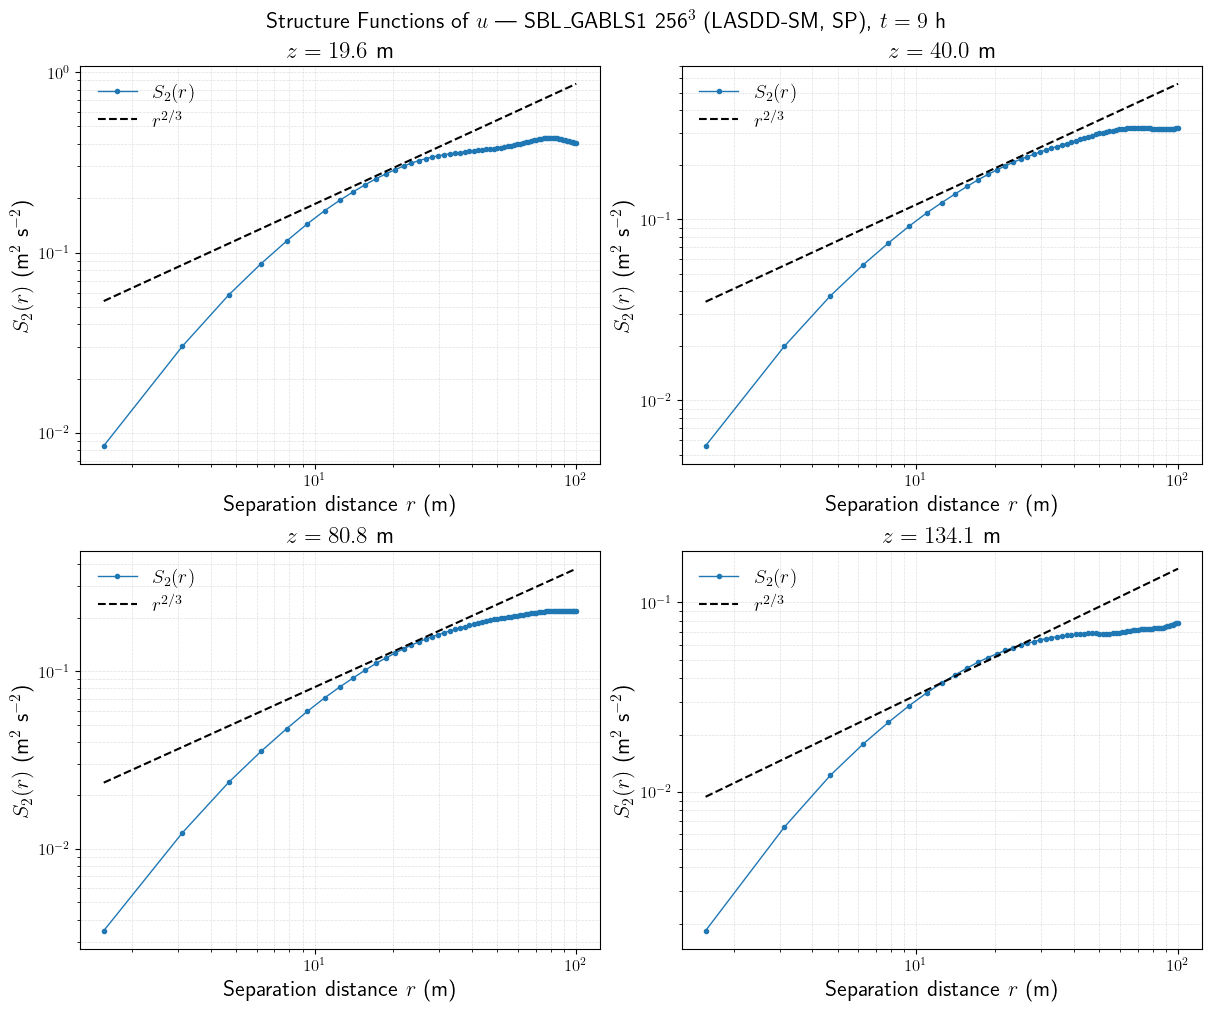

In [66]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axs = axs.flatten()

max_r   = nx // 4
A_ref_u = [4e-2, 2.6e-2, 1.75e-2, 7e-3]   # one pre-factor per height level; adjust to shift r^{2/3}

for i, k in enumerate(k_levels):
    S, rr = StructureFunction1D_LES(u3D[:, :, k], max_r=max_r)
    r_m = rr * dx

    ax = axs[i]
    ax.loglog(r_m, S[1], color='tab:blue', marker='o',
              markevery=1, markersize=3, linewidth=1.0, label=r'$S_2(r)$')
    ax.loglog(r_m, A_ref_u[i] * r_m ** (2 / 3), 'k--', linewidth=1.5, label=r'$r^{2/3}$')

    ax.set_title(rf'$z = {z_labels[i]}$ m')
    ax.set_xlabel(r'Separation distance $r$ (m)')
    ax.set_ylabel(r'$S_2(r)$ (m$^2$ s$^{-2}$)')
    ax.legend(frameon=False)
    ax.grid(True, which='both', ls='--', alpha=0.4)

fig.suptitle(r'Structure Functions of $u$ — SBL\_GABLS1 256$^3$ (LASDD-SM, SP), $t=9$ h', fontsize=16)
plt.show()

## Structure Functions of $\theta$

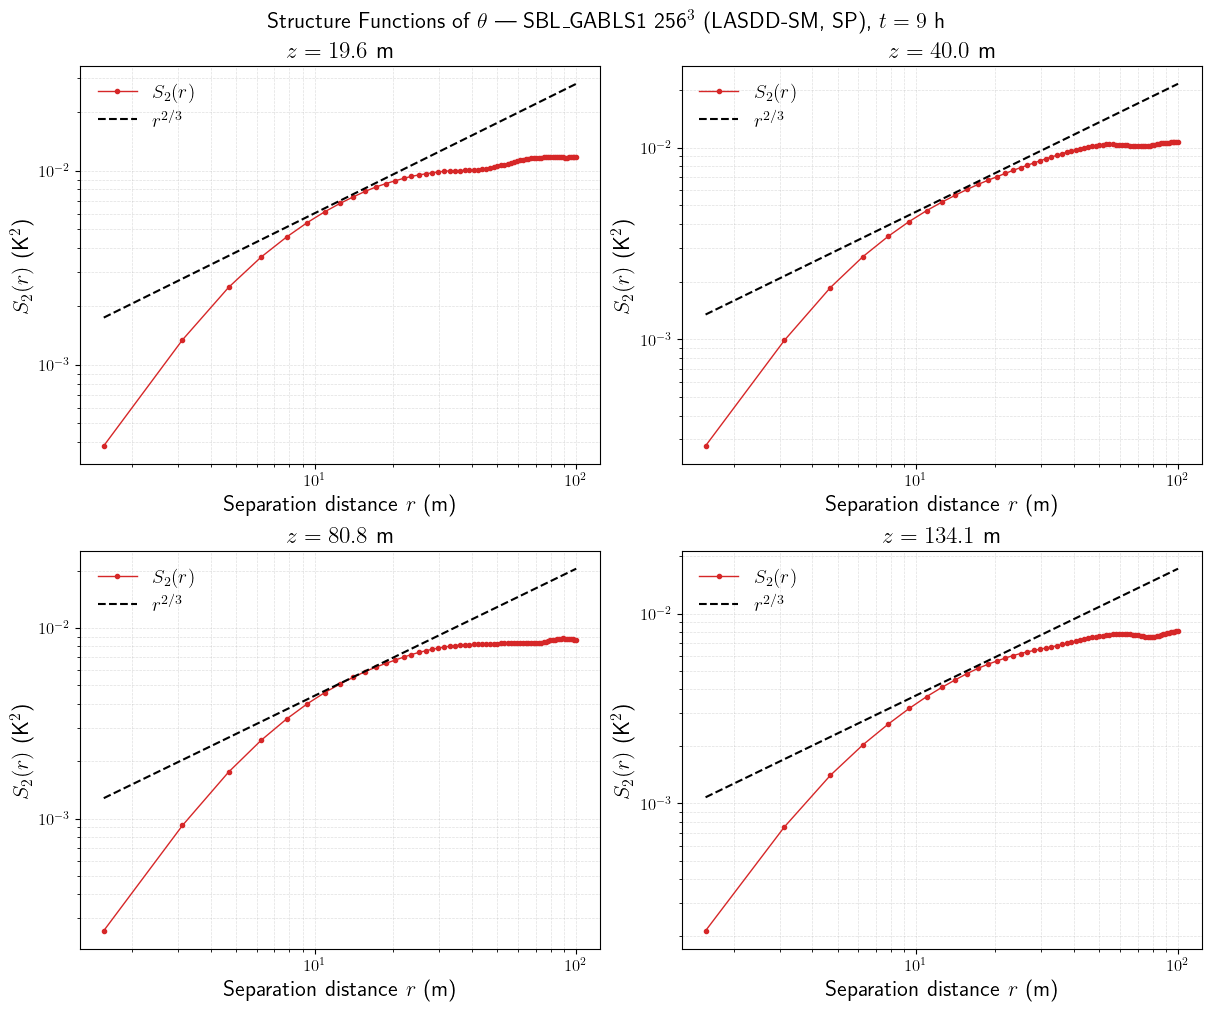

In [67]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axs = axs.flatten()

max_r    = nx // 4
A_ref_th = [1.3e-3, 1e-3, 0.95e-3, 0.8e-3]   # one pre-factor per height level; adjust to shift r^{2/3}

for i, k in enumerate(k_levels):
    S, rr = StructureFunction1D_LES(TH3D[:, :, k], max_r=max_r)
    r_m = rr * dx

    ax = axs[i]
    ax.loglog(r_m, S[1], color='tab:red', marker='o',
              markevery=1, markersize=3, linewidth=1.0, label=r'$S_2(r)$')
    ax.loglog(r_m, A_ref_th[i] * r_m ** (2 / 3), 'k--', linewidth=1.5, label=r'$r^{2/3}$')

    ax.set_title(rf'$z = {z_labels[i]}$ m')
    ax.set_xlabel(r'Separation distance $r$ (m)')
    ax.set_ylabel(r'$S_2(r)$ (K$^2$)')
    ax.legend(frameon=False)
    ax.grid(True, which='both', ls='--', alpha=0.4)

fig.suptitle(r'Structure Functions of $\theta$ — SBL\_GABLS1 256$^3$ (LASDD-SM, SP), $t=9$ h', fontsize=16)
plt.show()